# 추천 다양성 분석

## 분석 목적
사용자별 추천 콘텐츠의 다양성이 retention에 미치는 영향을 분석

## 핵심 가설
- 추천 다양성이 낮은 사용자일수록 D30 retention이 낮다.
- 같은 카테고리 추천 반복이 이탈의 원인이다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

df_events = pd.read_csv('events.csv')
df_users = pd.read_csv('users.csv')
df_amazon = pd.read_csv('amazon_cleaned.csv')

In [2]:
print(df_events.columns.tolist())

['user_id', 'segment', 'session_id', 'content_id', 'event_date', 'content_quality_score', 'completion_rate', 'is_skipped', 'watch_time_sec']


## 콘텐츠 카테고리 추출 및 이벤트 데이터에 결합

In [3]:
category_map = df_amazon.drop_duplicates('product_id')[['product_id', 'category_main']]
df_events = df_events.merge(category_map, left_on='content_id', right_on='product_id', how='left')
print(df_events[['user_id', 'content_id', 'category_main']].head())

    user_id  content_id          category_main
0  USR_0000  B0BN2576GQ           Home&Kitchen
1  USR_0000  B01M69WCZ6           Home&Kitchen
2  USR_0000  B01EJ5MM5M  Computers&Accessories
3  USR_0000  B08MV82R99           Home&Kitchen
4  USR_0000  B07LDPLSZC           Home&Kitchen


## 사용자별 추천 다양성 계산

In [4]:
from scipy.stats import entropy

def calc_entropy(categories):
    counts = categories.value_counts()
    probs = counts / counts.sum()
    return entropy(probs)

user_diversity = df_events.groupby('user_id')['category_main'].apply(calc_entropy).reset_index()
user_diversity.columns = ['user_id', 'diversity_entropy']

print(user_diversity.describe())

       diversity_entropy
count        1000.000000
mean            1.050183
std             0.214239
min             0.000000
25%             1.003742
50%             1.082196
75%             1.188427
max             1.475076


In [5]:
print(df_amazon['category_main'].value_counts())

category_main
Home&Kitchen             448
Electronics              392
Computers&Accessories    334
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


Amazon 데이터의 카테고리가 3개에 집중되어 있어 다양성 측정에 한계가 있음.   
실제 플랫폼에서는 다양한 카테고리가 존재하기 때문에 entropy범위도 넓어짐.

In [6]:
diversity_mean = user_diversity['diversity_entropy'].mean()

user_diversity['diversity_group'] = np.where(
    user_diversity['diversity_entropy'] >= diversity_mean,
    '다양성 상위 그룹',
    '다양성 하위 그룹'
)

print(user_diversity['diversity_group'].value_counts())

diversity_group
다양성 상위 그룹    632
다양성 하위 그룹    368
Name: count, dtype: int64


In [7]:
df_events['event_date'] = pd.to_datetime(df_events['event_date'])

first_session = df_events.groupby('user_id')['event_date'].min().reset_index()
first_session.columns = ['user_id', 'first_date']

df_retention = df_events.merge(first_session, on='user_id')
df_retention['days_since_first'] = (
    df_retention['event_date'] - df_retention['first_date']
).dt.days

d7 = df_retention[df_retention['days_since_first'].between(1, 7)]['user_id'].unique()
user_diversity['D7_retention'] = user_diversity['user_id'].isin(d7)

In [8]:
diversity_retention = user_diversity.groupby('diversity_group')['D7_retention'].mean() * 100
print(diversity_retention.round(1))

diversity_group
다양성 상위 그룹    40.5
다양성 하위 그룹    12.2
Name: D7_retention, dtype: float64


In [9]:
print(df_amazon['category_main'].value_counts())

category_main
Home&Kitchen             448
Electronics              392
Computers&Accessories    334
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


## 추천 다양성 그룹별 D7 Retention 비교

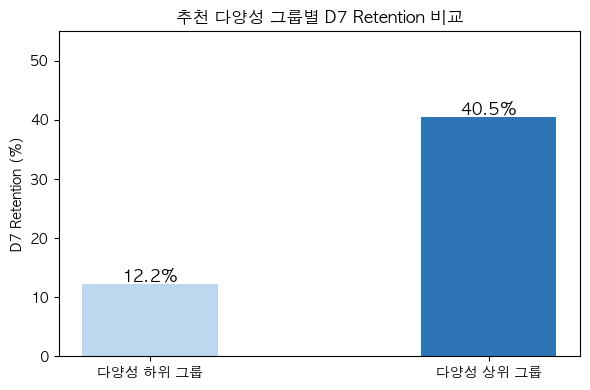

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

groups = ['다양성 하위 그룹', '다양성 상위 그룹']
values = [12.2, 40.5]
colors = ['#BDD7EE', '#2E75B6']

bars = ax.bar(groups, values, color=colors, width=0.4)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}%',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('D7 Retention (%)')
ax.set_title('추천 다양성 그룹별 D7 Retention 비교')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

## 핵심 인사이트
- 다양성 상위 그룹 D7 Retention = 40.5%
- 다양성 하위 그룹 D7 Retention = 12.2%
- 차이 = 28.3%p (3.3배)

## 한계
- Amazon 데이터 카테고리가 3개에 집중되어 entropy 범위가 제한적
- 카테고리가 랜덤 배분되어 인과관계 직접 증명 어려움

## 서비스 액션
추천 알고리즘에 다양성 constraint 추가
→ 동일 카테고리 연속 추천 제한